In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# reads dataset and replaces linebreaks and missing values with ''
data = []
with open('../datasets/chronic_kidney_disease_full.arff', "r") as f:
    for line in f:
        line = line.replace('\n', '')
        line = line.replace('?', '')
        line = line.replace('\t', '')
        data.append(line.split(','))

# gives names to the columns
names = ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba',
         'bgr', 'bu',  'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc',
         'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane',
         'class', 'no_name']
    
df = pd.DataFrame(data[145:], columns=names)
# np.nan is recognised as missing value for Pandas functions e.g. isnull()
df = df.replace('', np.nan)

df

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class,no_name
0,48,80,1.020,1,0,NaN,normal,notpresent,notpresent,121,...,7800,5.2,yes,yes,no,good,no,no,ckd,NaN
1,7,50,1.020,4,0,NaN,normal,notpresent,notpresent,NaN,...,6000,NaN,no,no,no,good,no,no,ckd,NaN
2,62,80,1.010,2,3,normal,normal,notpresent,notpresent,423,...,7500,NaN,no,yes,no,poor,no,yes,ckd,NaN
3,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,...,6700,3.9,yes,no,no,poor,yes,yes,ckd,NaN
4,51,80,1.010,2,0,normal,normal,notpresent,notpresent,106,...,7300,4.6,no,no,no,good,no,no,ckd,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,12,80,1.020,0,0,normal,normal,notpresent,notpresent,100,...,6600,5.4,no,no,no,good,no,no,notckd,NaN
398,17,60,1.025,0,0,normal,normal,notpresent,notpresent,114,...,7200,5.9,no,no,no,good,no,no,notckd,NaN
399,58,80,1.025,0,0,normal,normal,notpresent,notpresent,131,...,6800,6.1,no,no,no,good,no,no,notckd,NaN
400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
# Drop unwanted columns
df.drop(columns=['rbc', 'pc','pcc','ba','sc','htn','dm','cad','appet','pe','ane', 'no_name'], inplace=True)
df

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48,80,1.020,1,0,121,36,NaN,NaN,15.4,44,7800,5.2,ckd
1,7,50,1.020,4,0,NaN,18,NaN,NaN,11.3,38,6000,NaN,ckd
2,62,80,1.010,2,3,423,53,NaN,NaN,9.6,31,7500,NaN,ckd
3,48,70,1.005,4,0,117,56,111,2.5,11.2,32,6700,3.9,ckd
4,51,80,1.010,2,0,106,26,NaN,NaN,11.6,35,7300,4.6,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,12,80,1.020,0,0,100,26,137,4.4,15.8,49,6600,5.4,notckd
398,17,60,1.025,0,0,114,50,135,4.9,14.2,51,7200,5.9,notckd
399,58,80,1.025,0,0,131,18,141,3.5,15.8,53,6800,6.1,notckd
400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
# converts hemoglobin values from g/dl to d/l by multiplying by 10
# original type (str) is first converted to float, multiplied and then converted back
df['hemo'] = df['hemo'].astype('Float64')
df['hemo'] = df['hemo'].apply(lambda x: x*10)
df['hemo'] = df['hemo'].astype(str)
df

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48,80,1.020,1,0,121,36,NaN,NaN,154.0,44,7800,5.2,ckd
1,7,50,1.020,4,0,NaN,18,NaN,NaN,113.0,38,6000,NaN,ckd
2,62,80,1.010,2,3,423,53,NaN,NaN,96.0,31,7500,NaN,ckd
3,48,70,1.005,4,0,117,56,111,2.5,112.0,32,6700,3.9,ckd
4,51,80,1.010,2,0,106,26,NaN,NaN,116.0,35,7300,4.6,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,12,80,1.020,0,0,100,26,137,4.4,158.0,49,6600,5.4,notckd
398,17,60,1.025,0,0,114,50,135,4.9,142.0,51,7200,5.9,notckd
399,58,80,1.025,0,0,131,18,141,3.5,158.0,53,6800,6.1,notckd
400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
# recodes class values 'ckd' and 'notckd' (chronic kidney disease, control) to 'a' and 'c'
df['class'] = df['class'].replace({'ckd':'a', 'notckd':'c'})
df

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48,80,1.020,1,0,121,36,NaN,NaN,154.0,44,7800,5.2,a
1,7,50,1.020,4,0,NaN,18,NaN,NaN,113.0,38,6000,NaN,a
2,62,80,1.010,2,3,423,53,NaN,NaN,96.0,31,7500,NaN,a
3,48,70,1.005,4,0,117,56,111,2.5,112.0,32,6700,3.9,a
4,51,80,1.010,2,0,106,26,NaN,NaN,116.0,35,7300,4.6,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397,12,80,1.020,0,0,100,26,137,4.4,158.0,49,6600,5.4,c
398,17,60,1.025,0,0,114,50,135,4.9,142.0,51,7200,5.9,c
399,58,80,1.025,0,0,131,18,141,3.5,158.0,53,6800,6.1,c
400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
# remove rows with three or more missing values
df = df[df.isnull().sum(axis=1) < 3]
df

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48,80,1.020,1,0,121,36,NaN,NaN,154.0,44,7800,5.2,a
3,48,70,1.005,4,0,117,56,111,2.5,112.0,32,6700,3.9,a
4,51,80,1.010,2,0,106,26,NaN,NaN,116.0,35,7300,4.6,a
5,60,90,1.015,3,0,74,25,142,3.2,122.0,39,7800,4.4,a
6,68,70,1.010,0,0,100,54,104,4.0,124.0,36,NaN,NaN,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55,80,1.020,0,0,140,49,150,4.9,157.0,47,6700,4.9,c
396,42,70,1.025,0,0,75,31,141,3.5,165.0,54,7800,6.2,c
397,12,80,1.020,0,0,100,26,137,4.4,158.0,49,6600,5.4,c
398,17,60,1.025,0,0,114,50,135,4.9,142.0,51,7200,5.9,c


In [70]:
# reindex dataframe to correctly show the number of rows left
df = df.reset_index(drop=True)
df

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48,80,1.020,1,0,121,36,NaN,NaN,154.0,44,7800,5.2,a
1,48,70,1.005,4,0,117,56,111,2.5,112.0,32,6700,3.9,a
2,51,80,1.010,2,0,106,26,NaN,NaN,116.0,35,7300,4.6,a
3,60,90,1.015,3,0,74,25,142,3.2,122.0,39,7800,4.4,a
4,68,70,1.010,0,0,100,54,104,4.0,124.0,36,NaN,NaN,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,55,80,1.020,0,0,140,49,150,4.9,157.0,47,6700,4.9,c
261,42,70,1.025,0,0,75,31,141,3.5,165.0,54,7800,6.2,c
262,12,80,1.020,0,0,100,26,137,4.4,158.0,49,6600,5.4,c
263,17,60,1.025,0,0,114,50,135,4.9,142.0,51,7200,5.9,c


---

<h3>Task 2</h3>
<i>Split the data frame into two data frames, one for the affected individuals and one for the control individuals. Display the data frames, and indicate the number of rows in each data frame.</i>

---

First, we create a new data frame with only affected individuals based on the old data frame. We know that <b>all affected individuals have letter "a" in the class column</b>. So creating a new data frame with only affected individuals goes as followed...

In [71]:
df_affected = df[df["class"] == "a"] #create a new data frame with filter that has only people with "a" in the class.
df_affected #display the new data generated.

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
0,48,80,1.020,1,0,121,36,NaN,NaN,154.0,44,7800,5.2,a
1,48,70,1.005,4,0,117,56,111,2.5,112.0,32,6700,3.9,a
2,51,80,1.010,2,0,106,26,NaN,NaN,116.0,35,7300,4.6,a
3,60,90,1.015,3,0,74,25,142,3.2,122.0,39,7800,4.4,a
4,68,70,1.010,0,0,100,54,104,4.0,124.0,36,NaN,NaN,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,62,90,1.020,2,1,169,48,138,2.9,134.0,47,11000,6.1,a
122,64,90,1.015,3,2,463,64,135,4.1,122.0,40,9800,4.6,a
123,48,110,1.015,3,0,106,215,120,5.7,86.0,26,5000,2.5,a
124,59,70,1.010,1,3,424,55,138,4.5,126.0,37,10200,4.1,a


<b>Result:</b> Here we can see that we have 127 unique individuals affected by the disease. We created a new data frame called "df_affected", which contains only the people affected with the Chronic Kidney Disease.

---
So we continue, we have to now use the same technique to separate the people that are controlled for the individuals who's disease is progressing.

In [72]:
df_controlled = df[df["class"] == "c"] #create a new data frame with filter that has only people with "c" in the class.
df_controlled #display the new data generated.

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
126,40,80,1.025,0,0,140,10,135,5.0,150.0,48,10400,4.5,c
127,23,80,1.025,0,0,70,36,150,4.6,170.0,52,9800,5.0,c
128,45,80,1.025,0,0,82,49,147,4.4,159.0,46,9100,4.7,c
129,57,80,1.025,0,0,119,17,135,4.7,154.0,42,6200,6.2,c
130,51,60,1.025,0,0,99,38,135,3.7,130.0,49,8300,5.2,c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,55,80,1.020,0,0,140,49,150,4.9,157.0,47,6700,4.9,c
261,42,70,1.025,0,0,75,31,141,3.5,165.0,54,7800,6.2,c
262,12,80,1.020,0,0,100,26,137,4.4,158.0,49,6600,5.4,c
263,17,60,1.025,0,0,114,50,135,4.9,142.0,51,7200,5.9,c


<b>Result:</b>  Here we can see the list and amount of the contolled individuas, which is 138. Now we have to different data frames that have their on patients listed correctly.

<i>df_affected</i> = All the patients with the disease. (128 patients.) </br>
<i>df_controlled</i> = All the patients with sign of disease and being supervised. ( 139 patients. )

---

<h3>Task 3</h3>
For each data frame, calculate the basic statistics for each column, and provide clear, readable histograms for each numerical column. Do you see any outliers? If so, how would you handle them?

---

Next we check the data types in both data frames that we created on the previous step. We notice, that the data we want to calculate next is in a wrong format. Our first step is to greate for loop to easily change the needed data to a numerical type. 


In [73]:
df_affected.dtypes #Before calculating the basic statistics, we check the data types of each column.

age      str
bp       str
sg       str
al       str
su       str
bgr      str
bu       str
sod      str
pot      str
hemo     str
pcv      str
wbcc     str
rbcc     str
class    str
dtype: object

In [74]:
df_controlled.dtypes #From both new data frames

age      str
bp       str
sg       str
al       str
su       str
bgr      str
bu       str
sod      str
pot      str
hemo     str
pcv      str
wbcc     str
rbcc     str
class    str
dtype: object

In [75]:
for df in [df_affected, df_controlled]: #For loop for changin string data types to numeric values in 2 different data frames.
    df['age'] = df['age'].astype('Int64')
    df['bp'] = df['bp'].astype('Int64')
    df['sg'] = df['sg'].astype('Float64')
    df['al'] = df['al'].astype('Int64')
    df['su'] = df['su'].astype('Int64')
    df['bgr'] = df['bgr'].astype('Int64')
    df['bu'] = df['bu'].astype('Float64')
    df['sod'] = df['sod'].astype('Int64')
    df['pot'] = df['pot'].astype('Float64')
    df['hemo'] = df['hemo'].astype('Float64')
    df['pcv'] = df['pcv'].astype('Int64')
    df['wbcc'] = df['wbcc'].astype('Int64')
    df['rbcc'] = df['rbcc'].astype('Float64')

In [76]:
df_affected.dtypes

age        Int64
bp         Int64
sg       Float64
al         Int64
su         Int64
bgr        Int64
bu       Float64
sod        Int64
pot      Float64
hemo     Float64
pcv        Int64
wbcc       Int64
rbcc     Float64
class        str
dtype: object

In [77]:
df_controlled.dtypes

age        Int64
bp         Int64
sg       Float64
al         Int64
su         Int64
bgr        Int64
bu       Float64
sod        Int64
pot      Float64
hemo     Float64
pcv        Int64
wbcc       Int64
rbcc     Float64
class        str
dtype: object

<b>Result:</b> The for loop changed needed data to the right form. We made it sure by checking the data frame data types.

---
Now that we have data in a numeric format, we calculate the basic statistics from both data frames.

In [78]:
df_affected.describe(include='all') #Calculating the basic statistics

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
count,123.0,125.0,125.0,126.0,126.0,120.0,125.0,108.0,108.0,125.0,125.0,113.0,108.0,126
unique,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1
top,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,a
freq,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,126
mean,57.081301,80.72,1.01356,1.849206,0.809524,181.2,80.42,133.731481,4.751852,106.432,32.44,9450.442478,3.976852,NaN
std,14.465104,15.769305,0.004527,1.437038,1.366539,93.549394,60.501346,7.666661,4.203592,21.896507,7.150908,3720.458015,0.84451,NaN
min,6.0,50.0,1.005,0.0,0.0,22.0,1.5,104.0,2.5,31.0,9.0,2600.0,2.1,NaN
25%,49.5,70.0,1.01,0.25,0.0,107.0,37.0,131.75,3.8,95.0,29.0,7100.0,3.4,NaN
50%,60.0,80.0,1.015,2.0,0.0,158.0,60.0,136.0,4.2,108.0,33.0,9200.0,3.9,NaN
75%,65.0,90.0,1.015,3.0,1.0,241.25,107.0,139.0,4.9,120.0,37.0,11000.0,4.4,NaN


In [79]:
df_controlled.describe(include='all') #Calculating basic statistics

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc,class
count,138.0,136.0,138.0,138.0,138.0,134.0,134.0,135.0,135.0,136.0,137.0,135.0,135.0,138
unique,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1
top,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,c
freq,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,138
mean,46.362319,71.323529,1.0225,0.0,0.0,107.38806,32.761194,141.718519,4.341481,152.0,46.248175,7688.888889,5.385185,NaN
std,15.774387,8.59016,0.002509,0.0,0.0,18.818049,11.44991,4.806171,0.594174,12.819545,4.122715,1808.011469,0.593059,NaN
min,12.0,60.0,1.02,0.0,0.0,70.0,10.0,135.0,3.3,130.0,40.0,4300.0,4.5,NaN
25%,34.0,60.0,1.02,0.0,0.0,93.0,23.25,138.0,3.7,141.0,43.0,6300.0,4.9,NaN
50%,46.0,70.0,1.0225,0.0,0.0,107.5,32.5,141.0,4.5,150.0,46.0,7400.0,5.3,NaN
75%,58.0,80.0,1.025,0.0,0.0,123.75,44.0,146.0,4.9,162.0,50.0,9200.0,5.9,NaN


<b>Result:</b> We see the summary of the data in each calculable colum. Outlier that stood out in the <i>df_affected</i> data frame, is uniquelly low value in blood urea column <i>"1.5"</i>. Since it is uncertain if the result is correct, we leave it as it is. Any

---
Final step in the task 3 was to make a histogram. It is done by creating a function and calling it twice for each data frame.

In [80]:
def plot_data(df): #Function for making a histogram
    plt.figure(figsize=(20, 15))
    for i, col in enumerate(df.select_dtypes(include=['Int64', 'Float64'])):
        plt.subplot(5, 3, i + 1)
        df[col].plot(kind='hist', title=col)
        plt.xlabel(col)

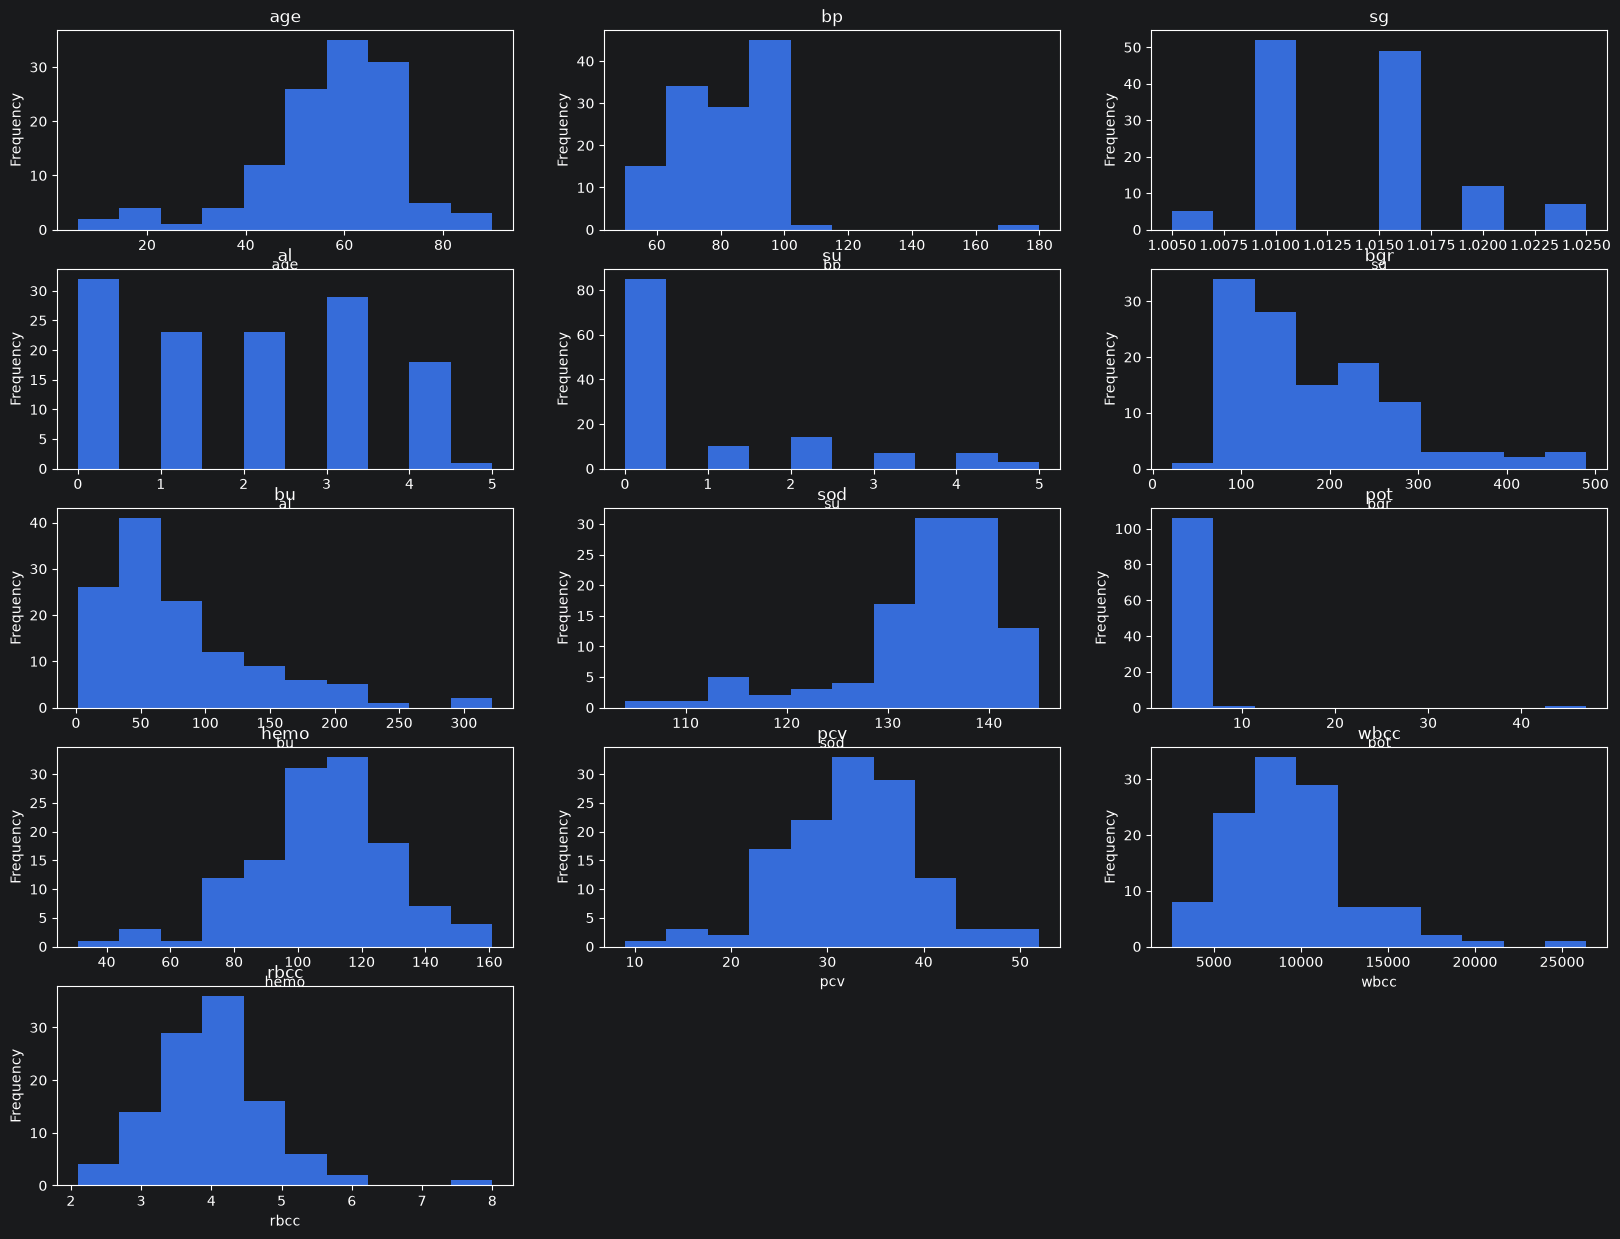

In [81]:
plot_data(df_affected) #Calling the function for data frame

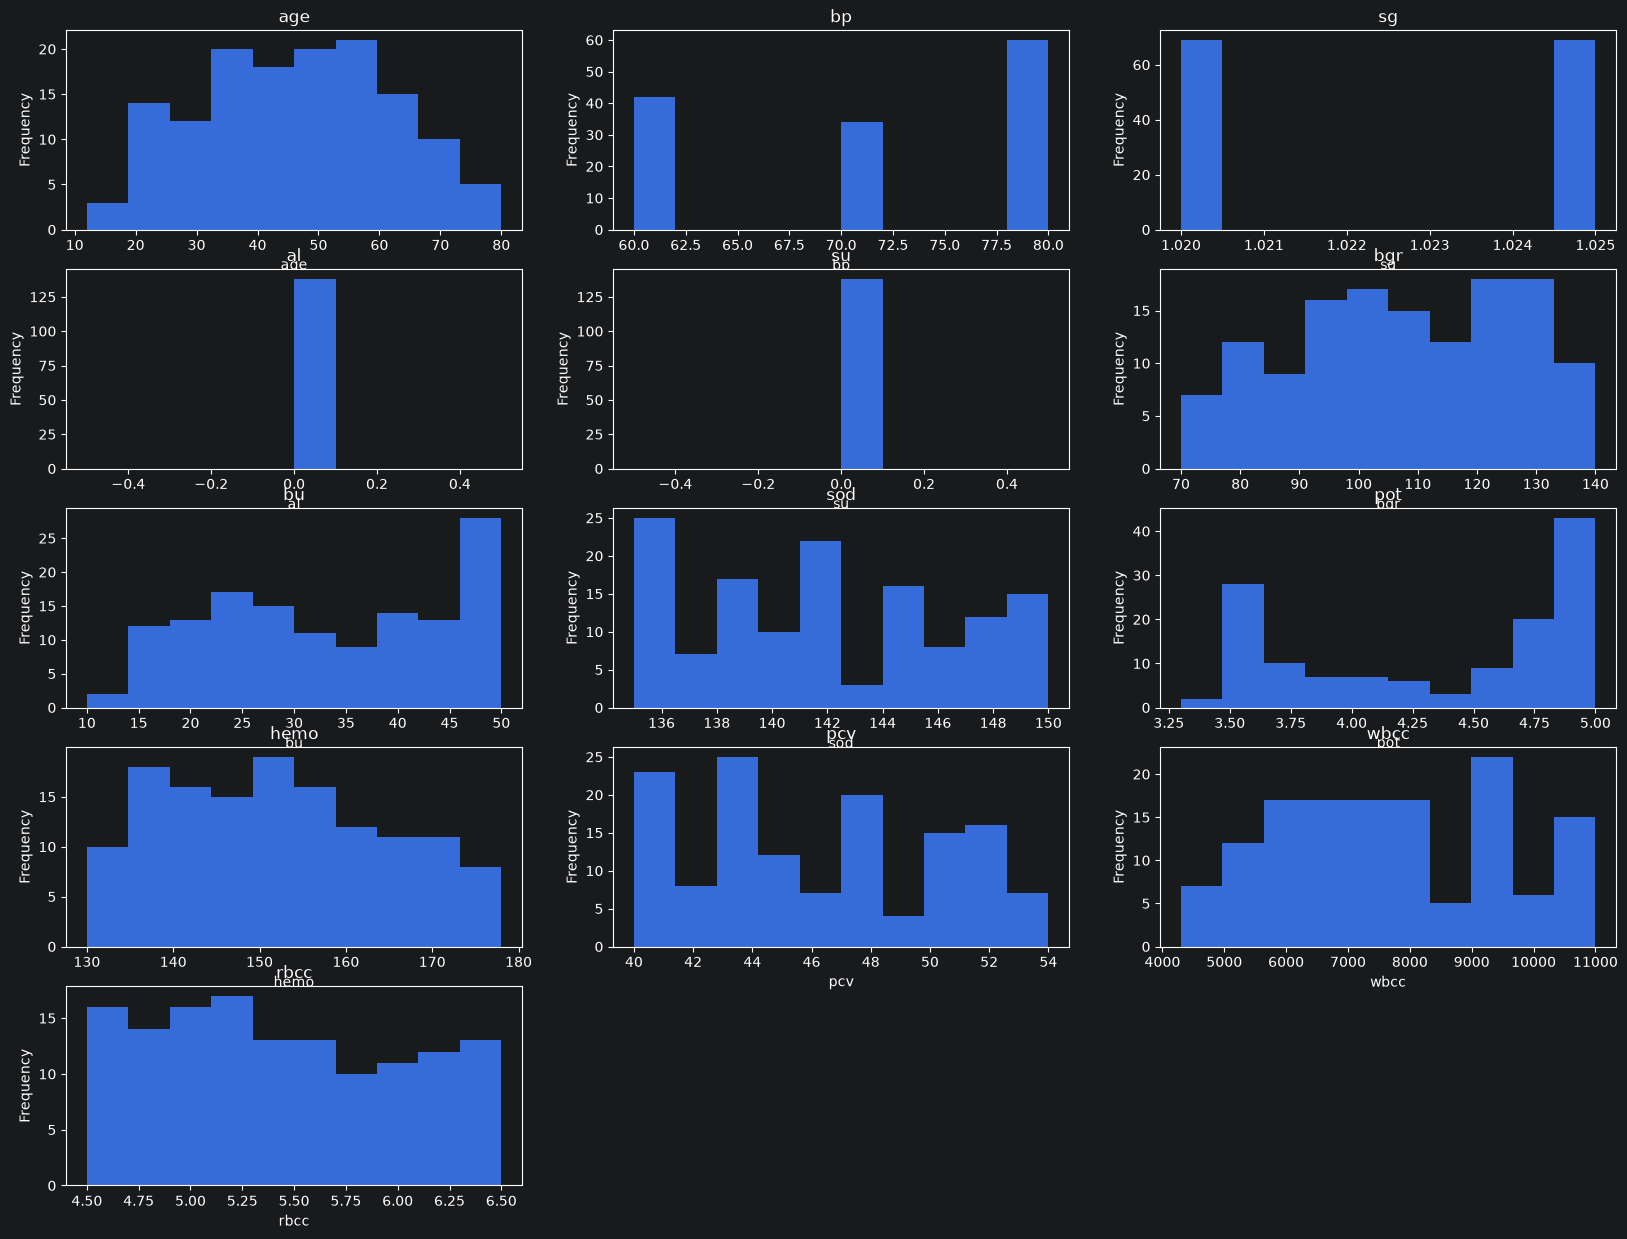

In [82]:
plot_data(df_controlled) #Calling the function for another data frame

<b>Result:</b> Finaly, we can see histograms from the data frames. Any other outliers seen above are left as they are, because the data might still be correct, even though the result is unique. 
    Ex. <i>df_affected</i> has a value of <b>300</b> in the blood pressure column, which is so high that it is life threatening. 

<h3>Task 4</h3>
Calculate the correlation matrix and visualize it for each data frame. Clearly describe the results and your interpretation for it.


First, we calculate the correlation matrices for the affected and control data frames. The correlation matrix shows how strongly the numerical variables are related to each other.

In [83]:
# Calculate correlation matrices for both data frames.
# The class column is excluded because correlation is calculated only for numerical columns.

corr_affected = df_affected.drop(columns=['class']).corr()
corr_controlled = df_controlled.drop(columns=['class']).corr()

print("Correlation matrix for affected individuals:")
display(corr_affected)

print("Correlation matrix for control individuals:")
display(corr_controlled)

Correlation matrix for affected individuals:


,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc
age,1.000000,0.061731,-0.004869,-0.016726,0.138945,0.205133,0.022593,-0.033951,-0.007490,-0.006174,-0.044467,0.015848,-0.016616
bp,0.061731,1.000000,0.066651,0.022210,0.181615,0.041162,0.064547,0.148208,0.068721,-0.097107,-0.104029,-0.040061,0.095163
sg,-0.004869,0.066651,1.000000,-0.061509,-0.044993,-0.083967,-0.037977,0.143235,0.046375,0.114042,0.106808,-0.026688,0.120779
al,-0.016726,0.022210,-0.061509,1.000000,0.115618,0.099096,0.426974,-0.179331,0.176842,-0.371257,-0.329337,0.067898,-0.231920
su,0.138945,0.181615,-0.044993,0.115618,1.000000,0.692159,-0.053597,0.052022,0.152143,0.184927,0.120275,0.103631,0.091519
bgr,0.205133,0.041162,-0.083967,0.099096,0.692159,1.000000,-0.029130,-0.053968,0.019949,0.144666,0.097501,0.049505,0.140348
bu,0.022593,0.064547,-0.037977,0.426974,-0.053597,-0.029130,1.000000,-0.320019,0.197928,-0.608652,-0.568745,-0.135999,-0.487755
sod,-0.033951,0.148208,0.143235,-0.179331,0.052022,-0.053968,-0.320019,1.000000,0.002814,0.295139,0.317933,0.019716,0.266934
pot,-0.007490,0.068721,0.046375,0.176842,0.152143,0.019949,0.197928,0.002814,1.000000,-0.181083,-0.198267,-0.169084,-0.185432
hemo,-0.006174,-0.097107,0.114042,-0.371257,0.184927,0.144666,-0.608652,0.295139,-0.181083,1.000000,0.951500,0.071613,0.779202


Correlation matrix for control individuals:


,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc
age,1.000000,-0.069901,-0.081145,NaN,NaN,0.103011,0.061539,0.105613,-0.077079,0.073905,-0.009291,0.112032,-0.032655
bp,-0.069901,1.000000,0.083649,NaN,NaN,0.004055,-0.082941,-0.107022,-0.066745,0.157302,-0.007913,-0.098158,-0.031807
sg,-0.081145,0.083649,1.000000,NaN,NaN,-0.038705,-0.040878,-0.030505,0.064551,0.017273,-0.007549,-0.017637,0.060363
al,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
su,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bgr,0.103011,0.004055,-0.038705,NaN,NaN,1.000000,-0.068162,-0.007837,0.147660,-0.148745,-0.257626,-0.069628,-0.197413
bu,0.061539,-0.082941,-0.040878,NaN,NaN,-0.068162,1.000000,0.001033,0.062216,0.099247,0.118530,0.027489,-0.001057
sod,0.105613,-0.107022,-0.030505,NaN,NaN,-0.007837,0.001033,1.000000,0.071280,-0.006639,-0.001280,0.336192,-0.089557
pot,-0.077079,-0.066745,0.064551,NaN,NaN,0.147660,0.062216,0.071280,1.000000,0.087298,-0.170716,0.057271,-0.063884
hemo,0.073905,0.157302,0.017273,NaN,NaN,-0.148745,0.099247,-0.006639,0.087298,1.000000,0.056992,-0.179888,0.067369


Next, we visualize both correlation matrices using heatmaps. This makes it easier to see the correlations between the variables.

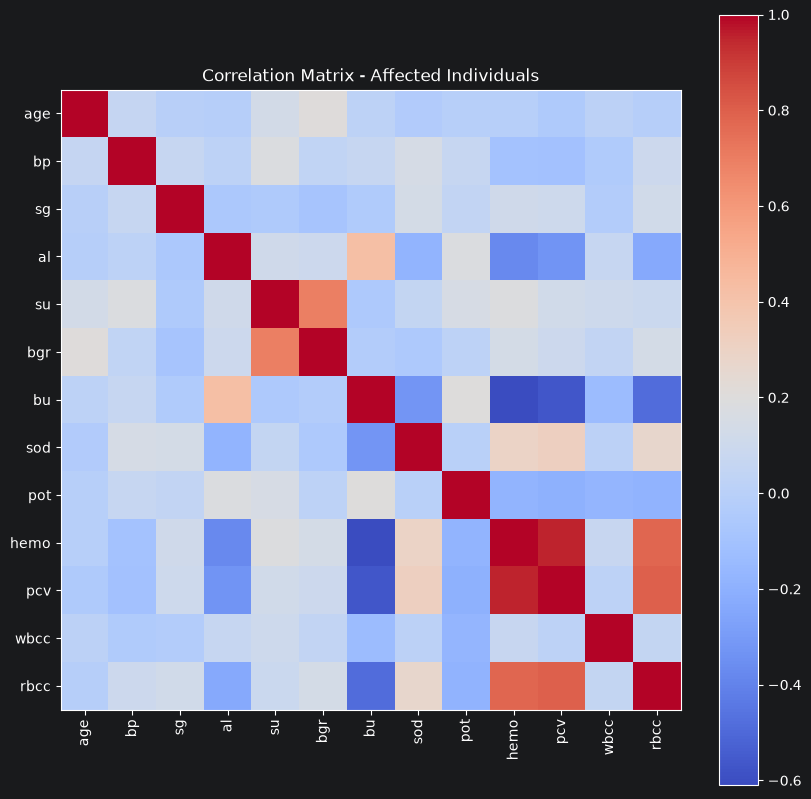

In [84]:
# Heatmap for affected individuals
plt.figure(figsize=(10, 10))
plt.imshow(corr_affected, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr_affected)), corr_affected.columns, rotation=90)
plt.yticks(range(len(corr_affected)), corr_affected.columns)
plt.title("Correlation Matrix - Affected Individuals")
plt.show()

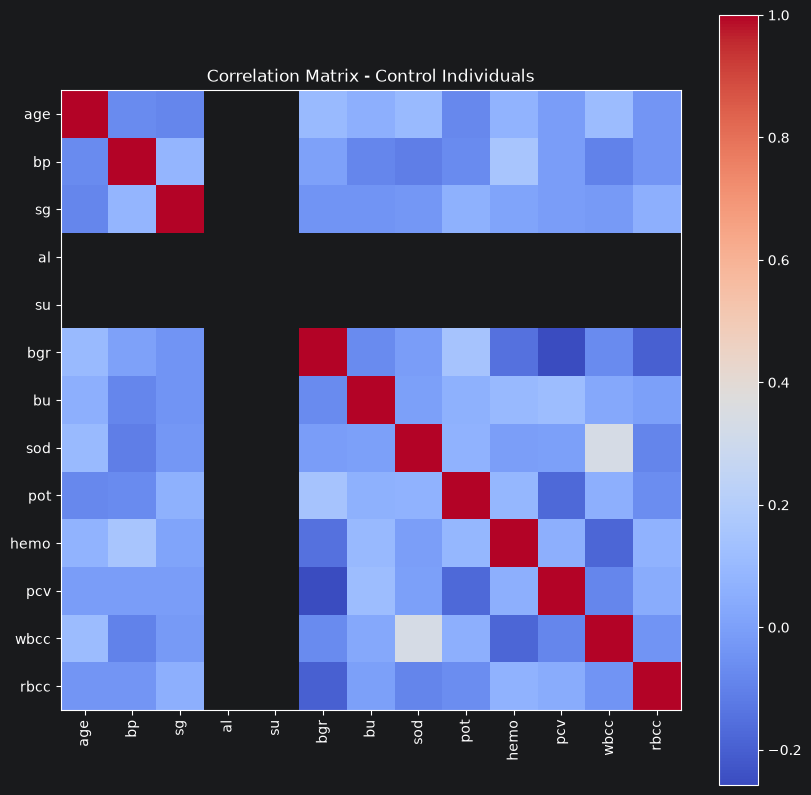

In [85]:
# Heatmap for control individuals
plt.figure(figsize=(10, 10))
plt.imshow(corr_controlled, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr_controlled)), corr_controlled.columns, rotation=90)
plt.yticks(range(len(corr_controlled)), corr_controlled.columns)
plt.title("Correlation Matrix - Control Individuals")
plt.show()

Result: The affected group has some strong correlations. For example, `hemo` and `pcv` have a strong positive
correlation of about 0.95, and `su` and `bgr` about 0.69. In the control group, most correlations are weaker. The
 `al` and `su` columns have NaN values because there is no variation in these columns. Correlation shows a
 relationship between variables, but it does not mean causation.